In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from astropy import units as u
from astropy.coordinates import SkyCoord

from astroquery.ipac.irsa import Irsa

from firefly_client import FireflyClient

# The time it takes to read SPHEREx files can exceed
# astropy's default timeout limit. Increase it.
from astropy.utils.data import conf
conf.remote_timeout = 120

In [302]:
# CrA 151
ra = 287.5840417
dec = -37.1408333

# R CrA IRS 7B
ra = 285.4852500    
dec = -36.9582500

# B335
ra = 294.2291667    
dec = 7.5733333

# Perseus B1c
ra = 53.325
dec = 31.16

# L1544 Taurus
ra = 76.0662917 
dec = 25.1992500

# LDN 183 Serpens
ra = 238.5508333    
dec = -2.8283333

# L1527 
ra = 69.9708333    
dec = 25.7500000

# LDN 260
ra = 251.7425000    
dec = -9.6055556

# LDN 1521
ra = 67.1620833
dec = 26.8597222

# LDN 1512
ra = 76.0404167    
dec = 32.7191667

# Ced 110
ra = 166.7956667    
dec = -77.3900333

## HH 46
ra = 126.4327083    
dec = -51.0090833

coord = SkyCoord(ra, dec, unit='deg')
search_radius = 1 * u.arcsec

In [214]:
# CrA 151
ra = 287.5840417
dec = -37.1408333

# B335
ra = 294.2291667    
dec = 7.5733333

# Perseus B1c
ra = 53.325
dec = 31.16

# L1498 Taurus
ra = 62.7500000     
dec = 24.9666667 

# R CrA IRS 7B
ra = 285.4852500    
dec = -36.9582500

coord = SkyCoord(ra, dec, unit='deg')
search_radius = 1 * u.arcsec

In [303]:
results = Irsa.query_sia(pos=(coord, search_radius), collection='spherex_qr2')

In [304]:
len(results)

399

In [5]:
fc = FireflyClient.make_client(url="https://irsa.ipac.caltech.edu/irsaviewer")

fc.reinit_viewer()

{'success': True}

In [305]:
c=0
for s in range(len(results)):
    spectral_image_url = results['access_url'][s]
    if 'D4_spx' in spectral_image_url:# and '1A' in spectral_image_url:
        print(spectral_image_url)
        c+=1
c

https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W19_1B/l2b-v20-2025-241/4/level2_2025W19_1B_0302_3D4_spx_l2b-v20-2025-241.fits
https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W19_1B/l2b-v20-2025-241/4/level2_2025W19_1B_0292_3D4_spx_l2b-v20-2025-241.fits
https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W19_1B/l2b-v20-2025-241/4/level2_2025W19_1B_0282_3D4_spx_l2b-v20-2025-241.fits
https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W19_1B/l2b-v20-2025-241/4/level2_2025W19_1B_0302_2D4_spx_l2b-v20-2025-241.fits
https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W19_1B/l2b-v20-2025-241/4/level2_2025W19_1B_0282_2D4_spx_l2b-v20-2025-241.fits
https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W19_1B/l2b-v20-2025-241/4/level2_2025W19_1B_0292_2D4_spx_l2b-v20-2025-241.fits
https://irsa.ipac.caltech.edu/ibe/data/spherex/qr2/level2/2025W22_1B/l2b-v20-2025-250/4/level2_2025W22_1B_0240_1D4_spx_l2b-v20-2025-250.fits
https://irsa.

88

In [9]:
fc.show_fits_image(file_input=spectral_image_url,
             plot_id="spectral_image",
             Title="Spectral Image"
             )

{'success': True}

In [182]:
#hdulist = fits.open('level2_2025W42_1A_0762_1D4_spx_l2b-v20-2025-292.fits')
hdulist = fits.open('level2_2025W36_1A_0361_1D4_spx_l2b-v20-2025-271.fits')
#hdulist = fits.open('B335-SPHEREx/level2_2025W39_1A_0628_4D4_spx_l2b-v20-2025-273.fits')
img = hdulist[1].data
wave = hdulist[6].data

In [268]:
hdulist.info()

Filename: level2_2025W36_1A_0361_1D4_spx_l2b-v20-2025-271.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1  IMAGE         1 ImageHDU       237   (2040, 2040)   float32   
  2  FLAGS         1 ImageHDU       146   (2040, 2040)   int32   
  3  VARIANCE      1 ImageHDU       119   (2040, 2040)   float32   
  4  ZODI          1 ImageHDU       119   (2040, 2040)   float32   
  5  PSF           1 ImageHDU       509   (101, 101, 121)   float32   
  6  WCS-WAVE      1 BinTableHDU     18   1R x 3C   ['13J', '20J', '520E']   


In [183]:
spectral_image_header = hdulist[1].header

keywords_to_print = ['EXTNAME', 'NAXIS1', 'NAXIS2', 'BUNIT', 'DETECTOR', 'OBSID', 'DATE', 'PSF_FWHM']

for keyword in keywords_to_print:
    value = spectral_image_header.get(keyword, 'Keyword not found')
    print(f"{keyword}: {value}")

EXTNAME: IMAGE
NAXIS1: 2040
NAXIS2: 2040
BUNIT: MJy / sr
DETECTOR: 4
OBSID: 2025W36_1A_0361_1
DATE: 2025-09-29T03:17:35.254
PSF_FWHM: 6.104327827908309


In [184]:
wcs = WCS(spectral_image_header)
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP' 'DEC--TAN-SIP' 
CRVAL : 75.8018788181 25.2042088768 
CRPIX : 1020.5 1020.5 
PC1_1 PC1_2  : -0.00170265132436 -0.000116474810584 
PC2_1 PC2_2  : -0.00018247629132 0.00170648988928 
CDELT : 1.0 1.0 
NAXIS : 2040  2040

In [185]:
ra, dec = wcs.wcs.crval
x, y = wcs.world_to_pixel(SkyCoord(ra=ra, dec=dec, unit="deg"))
print(ra, dec, x, y)
# Load the Spectral WCS from the header.
# Note that we need to provide a reference to HDU List, which contains a lookup table.
spectral_wcs = WCS(header=hdulist["IMAGE"].header, fobj=hdulist, key="W")

75.8018788181 25.2042088768 1019.0679847109604 1020.6585867893195
INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WC

In [186]:
# SIP distortions must be turned off for the spectral WCS.
spectral_wcs.sip = None
# The standard Astropy methods for converting pixel coordinates to world coordinates can also be used to obtain spectral coordinates.
# Take the pixel coordinates that we determined for the image center and resolve them to the wavelength and bandwidth for that pixel
wl, bw = spectral_wcs.pixel_to_world(x, y)
wl, bw
# Read in the spectral image data.
spectral_image = hdulist["IMAGE"]
spectral_image_data = spectral_image.data

# Get arrays of pixel coordinates for the image.
(y, x) = np.indices(spectral_image.shape)

# Use the spectral WCS to convert these pixel coordinates to spectral coordinates.
spectral_coords = spectral_wcs.pixel_to_world(x, y)

# Break out the two spectral coordinates (wavelength and bandwidth) from the spectral coordinates, and print the results.
wavelength, bandwidth = spectral_coords
print("Wavelength: \n", wavelength)
print("Bandwidth: \n", bandwidth)

Wavelength: 
 [[3.86285806 3.86280674 3.86275541 ... 3.8619858  3.86207133 3.86215687]
 [3.86200633 3.86195486 3.86190338 ... 3.86111471 3.86120011 3.8612855 ]
 [3.86115461 3.86110298 3.86105135 ... 3.86024363 3.86032888 3.86041413]
 ...
 [2.42846578 2.42841297 2.42836017 ... 2.42582855 2.42588149 2.42593442]
 [2.42815265 2.42809957 2.42804649 ... 2.42551605 2.42556934 2.42562264]
 [2.42783952 2.42778616 2.42773281 ... 2.42520355 2.4252572  2.42531085]] um
Bandwidth: 
 [[0.10407349 0.1040551  0.1040367  ... 0.09689784 0.09683195 0.09676607]
 [0.1040634  0.10404508 0.10402675 ... 0.09693611 0.0968708  0.0968055 ]
 [0.10405331 0.10403505 0.1040168  ... 0.09697437 0.09690965 0.09684493]
 ...
 [0.04193815 0.04195081 0.04196346 ... 0.04457723 0.04456189 0.04454656]
 [0.04169114 0.04170481 0.04171848 ... 0.04442959 0.04441288 0.04439617]
 [0.04144412 0.04145881 0.0414735  ... 0.04428196 0.04426387 0.04424579]] um


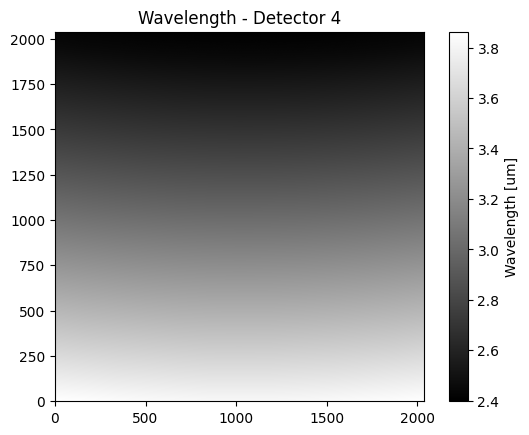

In [187]:
# Plot the wavelength as a greyscale color map across the image pixels.
plt.imshow(wavelength.value, origin='lower', cmap='gray')
plt.colorbar(label=f"Wavelength [{wavelength.unit}]")

detector = hdulist["IMAGE"].header["DETECTOR"]
plt.title(f"Wavelength - Detector {detector}")
plt.show()

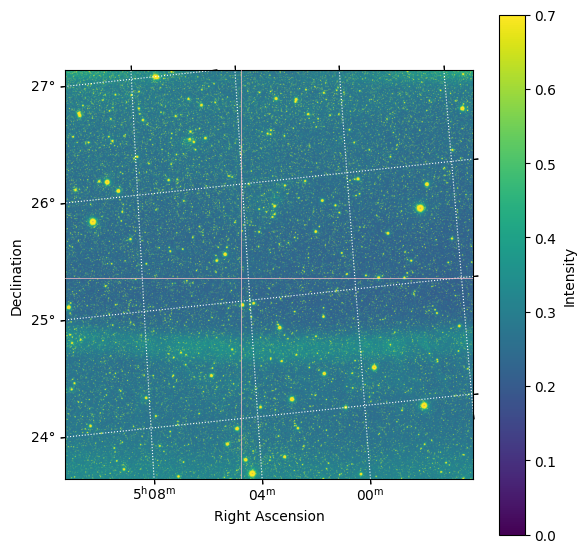

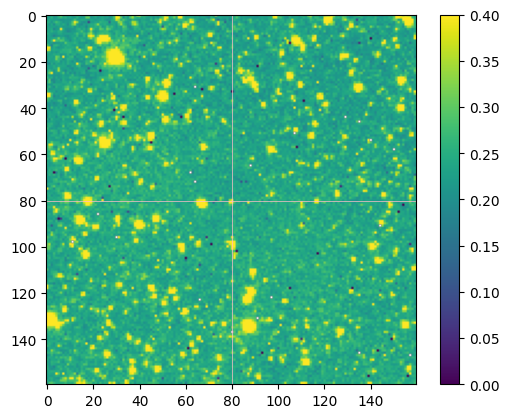

In [203]:
fig = plt.figure(figsize=(6, 6))
ax = plt.subplot(projection=wcs)

coord = SkyCoord(ra=287.5840417*u.deg, dec=-37.1408333*u.deg, frame="icrs")
coord = SkyCoord(ra=285.4852500*u.deg, dec=-36.9582500*u.deg, frame="icrs")

# L1154 Centre star
coord = SkyCoord(ra=76.0657917*u.deg, dec=25.1992500*u.deg, frame="icrs")

# L1154 Middle star
#coord = SkyCoord(ra=76.0905000*u.deg, dec=25.2023889*u.deg, frame="icrs")

# L1154 Edge star
#coord = SkyCoord(ra=76.0920417*u.deg, dec=25.1605000*u.deg, frame="icrs")

x, y = wcs.world_to_pixel(coord)
x1, x2 = int(x-80), int(x+80)
y1, y2 = int(y-80), int(y+80)

img = hdulist[1].data
x1, x2 = int(x-80), int(x+80)
y1, y2 = int(y-80), int(y+80)
arr = img.copy()#[y1:y2, x1:x2]
im = ax.imshow(arr, cmap="viridis", vmin=0, vmax=0.7)
arr = wavelength.value[930:1070, 770:910]
#im = ax.imshow(arr, origin="lower", cmap="tab20b", alpha=0.95)

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")

ax.coords.grid(True, color="white", ls="dotted")
ax.coords[0].set_format_unit("hourangle")  # RA in hh:mm:ss

#ax.scatter(x,y , edgecolor='r', facecolor='None', s=100)

plt.colorbar(im, ax=ax, label="Intensity")
plt.axhline(y, color='pink', lw=0.5)
plt.axvline(x, color='pink', lw=0.5)
plt.tight_layout()
plt.show()

plt.imshow(img[y1:y2, x1:x2], vmin=0, vmax=0.4 )
[plt.axvline(a, lw=0.5, color='pink') for a in [80]]
plt.axhline(80, lw=0.5, color='pink')
plt.colorbar()

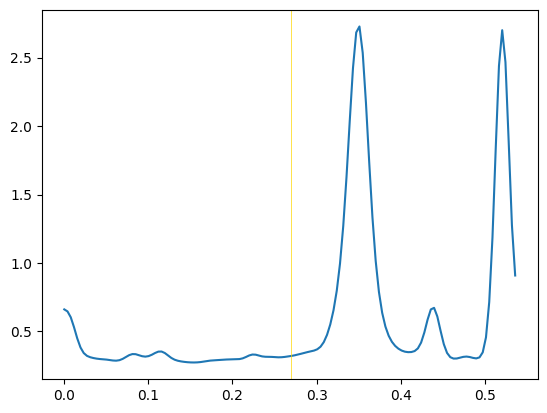

In [204]:
p1, p2 = int(x-70), int(x+70)
#p1, p2 = 0, -1
flux = img[100,p1:p2]
lam = wavelength.value[100,p1:p2]
sm = 2
flux = ndimage.gaussian_filter1d(flux, sm)
lam = np.arange(len(flux)) * 0.0017 * np.pi/180 * 130
plt.plot(lam, flux)
plt.axvline(lam[int(x+0.5)-p1], color='gold', lw=0.5)

(0.0, 0.5)

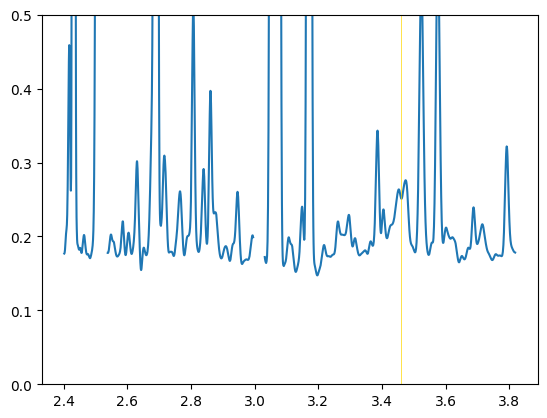

In [132]:
p1, p2 = 0,-1

flux = img[p1:p2,int(x+0.5)]
lam = wavelength.value[p1:p2,int(x+0.5)]
sm = 6
flux = ndimage.gaussian_filter1d(flux, sm)
plt.plot(lam, flux)
plt.axvline(lam[int(y+0.5)-p1], color='gold', lw=0.5)


flux = img[p1:p2,int(x+0.5)-11]
lam = wavelength.value[p1:p2,int(x+0.5)-11]
flux = ndimage.gaussian_filter1d(flux, sm)
#plt.plot(lam, flux)

plt.ylim(0,0.5)